In [148]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import sys
sys.path.append("../")
from src.preprocessing.pdf_extractor import PDFExtractor
from src.preprocessing.document_validator import DocumentValidator

In [149]:
# ---------------------------------------------------------
# LOAD FILES
# ---------------------------------------------------------
def load_vocab(file_path):
    with open(file_path, "r") as f:
        return json.load(f)

def load_embeddings(file_path):
    with open(file_path, "r") as f:
        data = json.load(f)

    # convert to numpy
    for k in data:
        data[k] = np.array(data[k])

    return data

In [150]:
STOPWORD_FILES = ["../data/stopwords/GBparl_stopwords-empirical.txt", "../data/stopwords/stopwords.txt"]

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def load_stopwords(custom_files):

    stopwords = set(ENGLISH_STOP_WORDS)

    # load domain stopwords
    for custom_file in custom_files:
        with open(custom_file, "r", encoding="utf-8") as f:
            for line in f:
                word = line.strip().lower()
                if word:
                    stopwords.add(word)

    return stopwords

stopwords = load_stopwords(STOPWORD_FILES)

In [151]:

import re

def clean_text(text, stopwords=None):

    # remove bullet characters
    text = text.replace("\uf0b7", " ")

    # remove numbering like "1." "2."
    text = re.sub(r"\n?\d+\.\s*", " ", text)

    # replace newlines with space
    text = text.replace("\n", " ")

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)
    
    # remove all punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # keep only alphabets, remove numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove numbers
    text = re.sub(r"\d+", " ", text)
    
    # make everything lowercase
    text = text.lower()

    # tokenize
    words = text.split()

    if stopwords:
        words = [w for w in words if w not in stopwords and len(w) > 2]
        
    # remove duplicates while preserving order
    seen = set()
    unique_words = []
    for w in words:
        if w not in seen:
            seen.add(w)
            unique_words.append(w)

    return " ".join(unique_words)

In [152]:
# ---------------------------------------------------------
# EXTRACT PARAGRAPHS FROM PDF
# ---------------------------------------------------------

def extract_paragraphs(pdf_path, skip_length=10):

    extractor = PDFExtractor()
    result = extractor.extract(pdf_path)

    paragraphs = [clean_text(seg["paragraph"], stopwords) for seg in result["segments"] if len(seg["paragraph"].split()) > skip_length]
    speakers = [seg["speaker"] for seg in result["segments"]]

    return paragraphs, speakers

In [153]:
# ---------------------------------------------------------
# VALIDATE DOCUMENT
# ---------------------------------------------------------

def validate(text):

    validator = DocumentValidator(vocab_path="../data/vocabulary/parliament_vocab.txt")
    results = validator.validate_document(text)

    return results

In [154]:
# ---------------------------------------------------------
# VOCAB BASED CLASSIFICATION
# ---------------------------------------------------------

def classify_vocab(paragraph, ministry_vocab):

    words = paragraph.lower().split()

    scores = {}

    for ministry, vocab in ministry_vocab.items():

        count = 0

        for term in vocab:
            if term.lower() in paragraph.lower():
                count += 1

        scores[ministry] = count

    total = sum(scores.values()) + 1e-9

    probs = {k: v / total for k, v in scores.items()}

    return probs


# ---------------------------------------------------------
# EMBEDDING BASED CLASSIFICATION
# ---------------------------------------------------------

def classify_embedding(paragraph, model, topic_embeddings):

    p_emb = model.encode(paragraph)

    scores = {}

    for topic, t_emb in topic_embeddings.items():

        sim = cosine_similarity(
            p_emb.reshape(1, -1),
            t_emb.reshape(1, -1)
        )[0][0]

        scores[topic] = float(sim)

    # softmax normalization
    exp_scores = np.exp(list(scores.values()))
    probs = exp_scores / np.sum(exp_scores)

    return dict(zip(scores.keys(), probs))

In [81]:
# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def run_pipeline(pdf_path):

    print(f"Processing: {pdf_path}")
    print("-" * 50)

    paragraphs, speaker = extract_paragraphs(pdf_path, skip_length=10)

    full_text = "\n\n".join(paragraphs)

    validation = validate(full_text)

    print("VALIDATION RESULTS:")
    print(json.dumps(validation, indent=4))

    if not validation["is_valid"]:
        print("Document failed validation")
        return

    print("\nLoading ministry vocab...")
    ministry_vocab = load_vocab("../data/vocabulary/ministry_tfidf_vocab.json")

    print("Loading topic embeddings...")
    topic_embeddings = load_embeddings("../data/embeddings/topic_embeddings.json")

    # load ministry topic mappings from csv
    topic_ministry_df = pd.read_csv("../data/topic_modeling/top_topics_per_ministry.csv")
    
    # one topic can belong to multiple ministries, so create list of ministries for each topic as key in topic_embeddings
    topic_to_ministries = {}
    for _, row in topic_ministry_df.iterrows():
        topic_id = str(row["TopicID"]) if "TopicID" in topic_ministry_df.columns else str(row["Topic"])
        if "Ministry" in topic_ministry_df.columns:
            ministry = row["Ministry"]

            if topic_id not in topic_to_ministries:
                topic_to_ministries[topic_id] = []

            topic_to_ministries[topic_id].append((ministry))
        elif "Ministries" in topic_ministry_df.columns:
            ministries = eval(str(row["Ministries"]))
            topic_to_ministries[topic_id] = ministries
    # replcae topic_embeddings keys with ministry names based on topic_to_ministries mapping
    topic_embeddings = {",".join(topic_to_ministries[topic]): emb for topic, emb in topic_embeddings.items() if topic in topic_to_ministries}

    model = SentenceTransformer("all-MiniLM-L6-v2", cache_folder="../models")

    print("\nClassifying paragraphs...\n")

    results = []

    for i, para in enumerate(paragraphs):

        vocab_probs = classify_vocab(para, ministry_vocab)

        embed_probs = classify_embedding(para, model, topic_embeddings)

        results.append({
            "paragraph_id": i,
            "paragraph": para,
            "speaker": speaker[i],
            "vocab_distribution": vocab_probs,
            "embedding_distribution": embed_probs
        })

        print("=" * 80)
        print(f"Paragraph {i}")
        # print(para[:200])

        print("\nTop vocab ministry:")
        print(sorted(vocab_probs.items(), key=lambda x: x[1], reverse=True)[:3])

        print("\nTop embedding ministry:")
        print(sorted(embed_probs.items(), key=lambda x: x[1], reverse=True)[:3])

    return results

In [82]:
# ---------------------------------------------------------
# RUN
# ---------------------------------------------------------

# if __name__ == "__main__":

file_name = "test.pdf"
file_path = f"../data/uploads/{file_name}"

results = run_pipeline(file_path)

Processing: ../data/uploads/test.pdf
--------------------------------------------------
VALIDATION RESULTS:905
{
    "is_valid": true,
    "is_english": true,
    "validation_errors": [],
    "vocab_size": 116,
    "required_vocab_matches": 5,
    "parliament_confidence": 0.06896551724137931,
    "matched_vocab_terms": [
        "act",
        "budget",
        "gazette",
        "government",
        "half",
        "motion",
        "schedule",
        "speaker"
    ]
}

Loading ministry vocab...
Loading topic embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Classifying paragraphs...

Paragraph 0

Top vocab ministry:
[('Ministry_of_Statistics_and_Programme_Implementation_MoSPI_', 0.1199999999952), ('Ministry_of_Parliamentary_Affairs_MPA_', 0.0799999999968), ('Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_', 0.0399999999984)]

Top embedding ministry:
[('Ministry_of_Development_of_North_Eastern_Region_MDoNER_,Ministry_of_Cooperation_MoC_', np.float64(0.05504070865363528)), ('Ministry_of_Power_MoP_,Ministry_of_New_and_Renewable_Energy_MNRE_,Ministry_of_Finance_MoF_', np.float64(0.05069322194798889)), ('Ministry_of_Statistics_and_Programme_Implementation_MoSPI_,Ministry_of_Planning_MoP_,Ministry_of_Parliamentary_Affairs_MPA_', np.float64(0.04899747921932631))]
Paragraph 1

Top vocab ministry:
[('Ministry_of_Coal_MoC_', 0.19999999998), ('Ministry_of_AYUSH_MoA_', 0.09999999999), ('Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_', 0.09999999999)]

Top embedding ministry:
[('Ministry_of_Rural_Development_MoRD_,Ministry_

In [83]:
len(results)

181

In [84]:
# find for which ministries the vocab and embedding classifications match
matches = []
for res in results:
    vocab_top = max(res["vocab_distribution"], key=res["vocab_distribution"].get)
    embed_top = max(res["embedding_distribution"], key=res["embedding_distribution"].get)

    if vocab_top in embed_top.split(","):
        matches.append({
            "paragraph_id": res["paragraph_id"],
            "speaker": res["speaker"],
            "ministry": vocab_top,
            "paragraph_snippet": res["paragraph"]
        })
print("\nParagraphs where vocab and embedding classifications match:")
for match in matches:
    print(f"Paragraph {match['paragraph_id']} - Speaker: {match['speaker']} - Ministry: {match['ministry']}")
    print(f"Snippet: {match['paragraph_snippet']}")
    print("-" * 80)


Paragraphs where vocab and embedding classifications match:
Paragraph 11 - Speaker: HON. SPEAKER - Ministry: Ministry_of_Panchayati_Raj_MoPR_
Snippet: programme rural women young farmers youth marginal landless families
--------------------------------------------------------------------------------
Paragraph 13 - Speaker: HON. SPEAKER - Ministry: Ministry_of_Food_Processing_Industries_MoFPI_
Snippet: aatmanirbharta pulses implementing edible oilseed achieving atmanirbhrata oils farmers capability grow needs
--------------------------------------------------------------------------------
Paragraph 14 - Speaker: HON. SPEAKER - Ministry: Ministry_of_Food_Processing_Industries_MoFPI_
Snippet: years ago concerted efforts succeeded achieving near selfsufficiency pulses farmers responded increasing cultivated area cent arranged procurement remunerative prices rising incomes better affordability consumption increased significantly
-------------------------------------------------------------

In [85]:
len(matches)

33

In [ ]:
# topic_ministry_mapping: 9 match (1 topic - 1 ministry : embedding using 1 vector per ministry)
# topic_ministry_mapping1: 27 match (1 topic - multiple ministries : embedding using 1 vector per ministry)
# topic_ministry_mapping2: 31 match (1 topic - multiple ministries : embedding using 1 average vector of all paragraphs per ministry)
# topic_ministry_mapping3_max: 31 match (1 topic - multiple ministries : embedding using average of 1 vector per paragraph per ministry)
# topic_ministry_mapping3_mean: 31 match (1 topic - multiple ministries : embedding using average of 1 vector per paragraph per ministry)
# topic_ministry_mapping3_top5: 32 match (1 topic - multiple ministries : embedding using average of 1 vector per paragraph per ministry)

# top_ministry_per_topic: 13 match (1 topic - 1 ministry: vocab based mapping)
# top_topics_per_ministry: 33 match (1 topic - multiple ministries: vocab based mapping)

In [1]:
import pandas as pd

In [2]:
state = pd.read_csv("../data/topic_modeling/state.csv")

In [26]:
# read ministry names from data/ministry_profiles (<ministry_name>.txt file for each ministry)
ministry_names = []
import os
for filename in os.listdir("../data/ministry_profiles"):
    if filename.endswith(".txt"):
        ministry_names.append(filename[:-4])  # remove .txt extension

ministry_names

['Ministry_of_Power_MoP_',
 'Ministry_of_Micro_Small_Medium_Enterprises_MoME_',
 'Ministry_of_AYUSH_MoA_',
 'Ministry_of_Textiles_MoT_',
 'Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_',
 'Ministry_of_Law_and_Justice_MoLJ_',
 'Ministry_of_Social_Justice_and_Empowerment_MoSJE_',
 'Ministry_of_Culture',
 'Ministry_of_Heavy_Industries_MoHI_',
 'Ministry_of_Statistics_and_Programme_Implementation_MoSPI_',
 'Ministry_of_Tourism_MoT_',
 'Ministry_of_External_Affairs_MEA_',
 'Ministry_of_Food_Processing_Industries_MoFPI_',
 'Ministry_of_Skill_Development_and_Entrepreneurship_MSDE_',
 'Ministry_of_Mines_MoM_',
 'Ministry_of_Consumer_Affairs_Food_and_Public_Distribution_MoCAF_PD_',
 'Ministry_of_Women_and_Child_Development_MoWCD_',
 'Ministry_of_Home_Affairs_MHA_',
 'Ministry_of_Petroleum_and_Natural_Gas_MoPNG_',
 'Ministry_of_Electronics_and_Information_Technology_MeitY_',
 'Ministry_of_Youth_Affairs_and_Sports_MoYAS_',
 'Ministry_of_Minority_Affairs_MoMA_',
 'Ministry_of_Rural_

In [ ]:
#replace topdocid in topic_docs with ministry name if it matches. then plot the distribution of ministries for each topic.
for i, row in state.iterrows():
    state.at[i, "DocID"] = ministry_names[row["DocID"]]
    
# rename DocID column to Ministry
state.rename(columns={"DocID": "Ministry"}, inplace=True)

/tmp/ipykernel_5272/793375447.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Ministry_of_Power_MoP_' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  state.at[i, "DocID"] = ministry_names[row["DocID"]]


In [40]:
# from Ministry columns, get the short ministry name by splitting at _ and taking the last part, if only 2 letters, then take last 2
state["Ministry_Short"] = state["Ministry"].apply(lambda x: x.split("_")[-2] if len(x.split("_")[-2]) > 2 else "_".join(x.split("_")[-3:-1]))

In [41]:
state

,Ministry,Word,Topic,Ministry_Short
0,Ministry_of_Power_MoP_,power,21,MoP
1,Ministry_of_Power_MoP_,mop,21,MoP
2,Ministry_of_Power_MoP_,power,21,MoP
3,Ministry_of_Power_MoP_,genesis,11,MoP
4,Ministry_of_Power_MoP_,historical,11,MoP
...,...,...,...,...
32804,Ministry_of_Labour_and_Employment_MoLE_,hazardous,19,MoLE
32805,Ministry_of_Labour_and_Employment_MoLE_,industry,0,MoLE
32806,Ministry_of_Labour_and_Employment_MoLE_,silicosis/pneumoconiosis,9,MoLE
32807,Ministry_of_Labour_and_Employment_MoLE_,occupational,19,MoLE


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# state has columns Ministry, Word, Topic
# since each word appears in multiple documents and different topics, i want to have a function which plots the topic distribution and document distribution given a word
def plot_word_distributions(word, state_df):

    word_data = state_df[state_df["Word"] == word]

    if word_data.empty:
        print(f"No data found for word: {word}")
        return

    topic_dist = word_data.groupby("Topic").size().reset_index(name="Count")
    doc_dist = word_data.groupby("Ministry_Short").size().reset_index(name="Count")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.barplot(x="Topic", y="Count", data=topic_dist)
    plt.title(f"Topic Distribution for Word: {word}")
    plt.xticks(rotation=45)

    plt.subplot(1, 2, 2)
    sns.barplot(x="Ministry_Short", y="Count", data=doc_dist)
    plt.title(f"Document Distribution for Word: {word}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

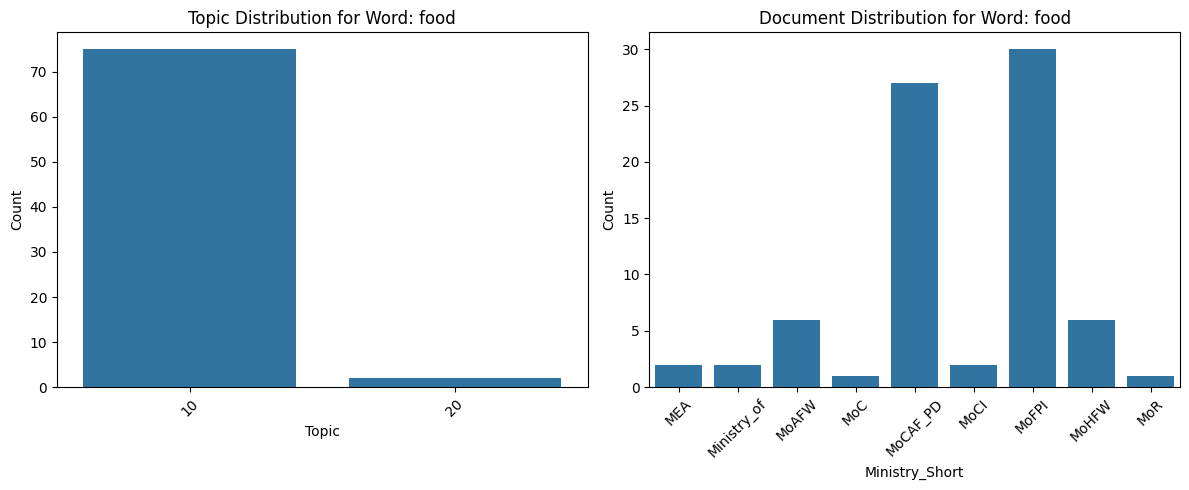

In [45]:
plot_word_distributions("food", state)

In [111]:
word_topic = pd.crosstab(state['Word'], state['Topic'], normalize='index')

word_doc = pd.crosstab(state['Word'], state['Ministry'], normalize='index')

topic_doc = pd.crosstab(state['Topic'], state['Ministry'], normalize='index')

In [ ]:
# -----------------------------
# PREPROCESS FUNCTION
# -----------------------------
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    return words


# -----------------------------
# CLASSIFIER FUNCTION
# -----------------------------
def classify_paragraph(paragraph):

    words = preprocess(paragraph)

    scores = defaultdict(float)

    for word in words:

        # skip unseen words
        if word not in word_doc.index:
            continue

        for doc in word_doc.columns:

            P_doc_w = word_doc.loc[word, doc]

            topic_sum = 0

            for topic in word_topic.columns:
                topic_sum += (
                    word_topic.loc[word, topic] *
                    topic_doc.loc[topic, doc]
                )

            scores[doc] += P_doc_w * topic_sum

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    # normalize scores to sum to 1
    total_score = sum(score for _, score in sorted_scores) + 1e-9
    normalized_scores = [(doc, round(score / total_score, 4)) for doc, score in sorted_scores]
    return normalized_scores

In [142]:
paragraph = """
alternate investment funds aifs category undertaking investments infrastructure sectors propose provide certainty taxation entities gains securities
"""

classify_paragraph(paragraph)

[('Ministry_of_Finance_MoF_', np.float64(0.4899)),
 ('Ministry_of_Communications_MoC_', np.float64(0.2692)),
 ('Ministry_of_Heavy_Industries_MoHI_', np.float64(0.0744)),
 ('Ministry_of_Commerce_and_Industry_MoCI_', np.float64(0.0347)),
 ('Ministry_of_Corporate_Affairs_MCA_', np.float64(0.0293)),
 ('Ministry_of_Micro_Small_Medium_Enterprises_MoME_', np.float64(0.0099)),
 ('Ministry_of_Chemicals_and_Fertilizers_MoCF_', np.float64(0.008)),
 ('Ministry_of_AYUSH_MoA_', np.float64(0.0074)),
 ('Ministry_of_Development_of_North_Eastern_Region_MDoNER_',
  np.float64(0.0067)),
 ('Ministry_of_Housing_and_Urban_Affairs_MoHUA_', np.float64(0.0061)),
 ('Ministry_of_Education_MoE_', np.float64(0.0056)),
 ('Ministry_of_External_Affairs_MEA_', np.float64(0.0054)),
 ('Ministry_of_Food_Processing_Industries_MoFPI_', np.float64(0.0051)),
 ('Ministry_of_Fisheries_Animal_Husbandry_and_Dairying_MoFAHD_',
  np.float64(0.0033)),
 ('Ministry_of_Women_and_Child_Development_MoWCD_', np.float64(0.0032)),
 ('Minist

In [125]:
# P(word | topic)
topic_word = pd.crosstab(
    state['Topic'],
    state['Word'],
    normalize='index'
)

# P(topic | doc)
doc_topic = pd.crosstab(
    state['Ministry'],
    state['Topic'],
    normalize='index'
)

# P(doc)
P_doc = state['Ministry'].value_counts(normalize=True).to_dict()

In [ ]:
def classify_paragraph_bayesian(paragraph):

    words = preprocess(paragraph)

    scores = {}

    for doc in doc_topic.index:

        # Start with log prior
        score = np.log(P_doc.get(doc, 1e-9))

        for word in words:

            if word not in topic_word.columns:
                continue

            likelihood = 0

            for topic in topic_word.index:

                P_w_t = topic_word.loc[topic, word]      # P(word|topic)
                P_t_d = doc_topic.loc[doc, topic]        # P(topic|doc)

                likelihood += P_w_t * P_t_d

            # Avoid log(0)
            score += np.log(likelihood + 1e-9)

        scores[doc] = score

    # Convert log-scores to probabilities via softmax
    max_score = max(scores.values())

    exp_scores = {
        doc: np.exp(score - max_score)
        for doc, score in scores.items()
    }

    total = sum(exp_scores.values())

    normalized_scores = [
        (doc, round(score / total, 4))
        for doc, score in sorted(exp_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    return normalized_scores

In [143]:
paragraph = """
alternate investment funds aifs category undertaking investments infrastructure sectors propose provide certainty taxation entities gains securities
"""

classify_paragraph_bayesian(paragraph)

[('Ministry_of_New_and_Renewable_Energy_MNRE_', np.float64(0.8906)),
 ('Ministry_of_Finance_MoF_', np.float64(0.0865)),
 ('Ministry_of_Heavy_Industries_MoHI_', np.float64(0.0164)),
 ('Ministry_of_Communications_MoC_', np.float64(0.0061)),
 ('Ministry_of_Power_MoP_', np.float64(0.0002)),
 ('Ministry_of_Statistics_and_Programme_Implementation_MoSPI_',
  np.float64(0.0001)),
 ('Ministry_of_Environment_Forest_and_Climate_Change_MoEFCC_',
  np.float64(0.0)),
 ('Ministry_of_Food_Processing_Industries_MoFPI_', np.float64(0.0)),
 ('Ministry_of_Housing_and_Urban_Affairs_MoHUA_', np.float64(0.0)),
 ('Ministry_of_Science_and_Technology_MST_', np.float64(0.0)),
 ('Ministry_of_Petroleum_and_Natural_Gas_MoPNG_', np.float64(0.0)),
 ('Ministry_of_Women_and_Child_Development_MoWCD_', np.float64(0.0)),
 ('Ministry_of_Commerce_and_Industry_MoCI_', np.float64(0.0)),
 ('Ministry_of_Ports_Shipping_and_Waterways_MoPSW_', np.float64(0.0)),
 ('Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_', np.float64(0.0

In [147]:
# convert list of touple (_, _) to dict {_: _}
def list_to_dict(lst):
    return {k: v for k, v in lst}

In [164]:
# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def run_pipeline(pdf_path):

    print(f"Processing: {pdf_path}")
    print("-" * 50)

    paragraphs, speaker = extract_paragraphs(pdf_path, skip_length=10)

    full_text = "\n\n".join(paragraphs)

    validation = validate(full_text)

    print("VALIDATION RESULTS:")
    print(json.dumps(validation, indent=4))

    if not validation["is_valid"]:
        print("Document failed validation")
        return

    print("\nLoading ministry vocab...")
    ministry_vocab = load_vocab("../data/vocabulary/ministry_tfidf_vocab.json")

    print("\nClassifying paragraphs...\n")

    results = []

    for i, para in enumerate(paragraphs):

        vocab_probs = classify_vocab(para, ministry_vocab)
        
        vocab_probs2 = list_to_dict(classify_paragraph(para))

        results.append({
            "paragraph_id": i,
            "paragraph": para,
            "speaker": speaker[i],
            "vocab_distribution": vocab_probs,
            "embedding_distribution": vocab_probs2
        })

        print("=" * 80)
        print(f"Paragraph {i}")
        # print(para[:200])

        print("\nTop vocab ministry:")
        print(sorted(vocab_probs.items(), key=lambda x: x[1], reverse=True)[:3])

        print("\nTop embedding ministry:")
        print(sorted(vocab_probs2.items(), key=lambda x: x[1], reverse=True)[:3])

    return results

In [165]:
# ---------------------------------------------------------
# RUN
# ---------------------------------------------------------

# if __name__ == "__main__":

file_name = "test.pdf"
file_path = f"../data/uploads/{file_name}"

results = run_pipeline(file_path)

Processing: ../data/uploads/test.pdf
--------------------------------------------------
VALIDATION RESULTS:905
{
    "is_valid": true,
    "is_english": true,
    "validation_errors": [],
    "vocab_size": 116,
    "required_vocab_matches": 5,
    "parliament_confidence": 0.06896551724137931,
    "matched_vocab_terms": [
        "act",
        "budget",
        "gazette",
        "government",
        "half",
        "motion",
        "schedule",
        "speaker"
    ]
}

Loading ministry vocab...

Classifying paragraphs...

Paragraph 0

Top vocab ministry:
[('Ministry_of_Statistics_and_Programme_Implementation_MoSPI_', 0.1199999999952), ('Ministry_of_Parliamentary_Affairs_MPA_', 0.0799999999968), ('Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_', 0.0399999999984)]

Top embedding ministry:
[('Ministry_of_Commerce_and_Industry_MoCI_', np.float64(0.6835)), ('Ministry_of_Cooperation_MoC_', np.float64(0.0994)), ('Ministry_of_Rural_Development_MoRD_', np.float64(0.0729))]
Par

In [166]:
# find for which ministries the vocab and embedding classifications match
matches = []
for res in results:
    vocab_top = max(res["vocab_distribution"], key=res["vocab_distribution"].get)
    embed_top = max(res["embedding_distribution"], key=res["embedding_distribution"].get)
    # consider top ministries in 0.1 probability range for embedding classification
    embed_top_score = res["embedding_distribution"][embed_top]
    embed_top_candidates = [k for k, v in res["embedding_distribution"].items() if embed_top_score-v <= 0.1]

    if vocab_top in embed_top_candidates[:3]:
        matches.append({
            "paragraph_id": res["paragraph_id"],
            "speaker": res["speaker"],
            "ministry": vocab_top,
            "paragraph_snippet": res["paragraph"]
        })
print("\nParagraphs where vocab and embedding classifications match:")
for match in matches:
    print(f"Paragraph {match['paragraph_id']} - Speaker: {match['speaker']} - Ministry: {match['ministry']}")
    print(f"Snippet: {match['paragraph_snippet']}")
    print("-" * 80)
    
print(len(matches))


Paragraphs where vocab and embedding classifications match:
Paragraph 9 - Speaker: HON. SPEAKER - Ministry: Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
Snippet: prime dhandhaanya krishi yojana developing agri districts programme motivated success aspirational undertake partnership states convergence existing schemes measures cover low productivity moderate crop intensity belowaverage credit parameters enhance agricultural adopt diversification sustainable agriculture practices augment postharvest storage panchayat block level improve irrigation facilities facilitate availability longterm shortterm likely help crore farmers
--------------------------------------------------------------------------------
Paragraph 10 - Speaker: HON. SPEAKER - Ministry: Ministry_of_Rural_Development_MoRD_
Snippet: building rural prosperity resilience comprehensive multisectoral programme launched partnership states address underemployment agriculture skilling investment technology invigorating eco

In [167]:
# ---------------------------------------------------------
# MAIN PIPELINE
# ---------------------------------------------------------

def run_pipeline(pdf_path):

    print(f"Processing: {pdf_path}")
    print("-" * 50)

    paragraphs, speaker = extract_paragraphs(pdf_path, skip_length=10)

    full_text = "\n\n".join(paragraphs)

    validation = validate(full_text)

    print("VALIDATION RESULTS:")
    print(json.dumps(validation, indent=4))

    if not validation["is_valid"]:
        print("Document failed validation")
        return

    print("\nLoading ministry vocab...")
    ministry_vocab = load_vocab("../data/vocabulary/ministry_tfidf_vocab.json")
    
    print("Loading ministry embeddings...")
    ministry_embeddings = load_embeddings("../data/embeddings/ministry_embeddings2.json")

    model = SentenceTransformer("all-MiniLM-L6-v2", cache_folder="../models")      

    print("\nClassifying paragraphs...\n")

    results = []

    for i, para in enumerate(paragraphs):

        vocab_probs = classify_vocab(para, ministry_vocab)
        
        vocab_probs2 = list_to_dict(classify_paragraph(para))
        
        embed_probs = classify_embedding(
            para,
            model,
            ministry_embeddings
        )

        results.append({
            "paragraph_id": i,
            "paragraph": para,
            "speaker": speaker[i],
            "vocab_distribution": vocab_probs,
            "vocab2_distribution": vocab_probs2,
            "embedding_distribution": embed_probs
        })

        print("=" * 80)
        print(f"Paragraph {i}")
        # print(para[:200])

        print("\nTop vocab ministry:")
        print(sorted(vocab_probs.items(), key=lambda x: x[1], reverse=True)[:3])

        print("\nTop vocab2 ministry:")
        print(sorted(vocab_probs2.items(), key=lambda x: x[1], reverse=True)[:3])

        print("\nTop embedding ministry:")
        print(sorted(embed_probs.items(), key=lambda x: x[1], reverse=True)[:3])

    return results

In [168]:
# ---------------------------------------------------------
# RUN
# ---------------------------------------------------------

# if __name__ == "__main__":

file_name = "test.pdf"
file_path = f"../data/uploads/{file_name}"

results = run_pipeline(file_path)

Processing: ../data/uploads/test.pdf
--------------------------------------------------
VALIDATION RESULTS:905
{
    "is_valid": true,
    "is_english": true,
    "validation_errors": [],
    "vocab_size": 116,
    "required_vocab_matches": 5,
    "parliament_confidence": 0.06896551724137931,
    "matched_vocab_terms": [
        "act",
        "budget",
        "gazette",
        "government",
        "half",
        "motion",
        "schedule",
        "speaker"
    ]
}

Loading ministry vocab...
Loading ministry embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Classifying paragraphs...

Paragraph 0

Top vocab ministry:
[('Ministry_of_Statistics_and_Programme_Implementation_MoSPI_', 0.1199999999952), ('Ministry_of_Parliamentary_Affairs_MPA_', 0.0799999999968), ('Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_', 0.0399999999984)]

Top vocab2 ministry:
[('Ministry_of_Commerce_and_Industry_MoCI_', np.float64(0.6835)), ('Ministry_of_Cooperation_MoC_', np.float64(0.0994)), ('Ministry_of_Rural_Development_MoRD_', np.float64(0.0729))]

Top embedding ministry:
[('Ministry_of_Parliamentary_Affairs_MPA_', np.float64(0.023907633264838038)), ('Ministry_of_Cooperation_MoC_', np.float64(0.02140455957184313)), ('Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_', np.float64(0.021267114843822828))]
Paragraph 1

Top vocab ministry:
[('Ministry_of_Coal_MoC_', 0.19999999998), ('Ministry_of_AYUSH_MoA_', 0.09999999999), ('Ministry_of_Personnel_Public_Grievances_and_Pensions_MoPPGP_', 0.09999999999)]

Top vocab2 ministry:
[('Ministry_of_Yo

In [180]:
# find for which ministries the vocab and embedding or vocab2 and embedding or vocab and vocab2 classifications match
matches = []
for res in results:
    vocab_top = max(res["vocab_distribution"], key=res["vocab_distribution"].get)
    vocab2_top = max(res["vocab2_distribution"], key=res["vocab2_distribution"].get)
    embed_top = max(res["embedding_distribution"], key=res["embedding_distribution"].get)
    # consider top ministries in 0.1 probability range for embedding classification
    vocab2_top_score = res["vocab2_distribution"][vocab2_top]
    vocab2_top_candidates = [k for k, v in res["vocab2_distribution"].items() if vocab2_top_score-v <= 0.1]

    if vocab_top in vocab2_top_candidates[:3] or embed_top in vocab2_top_candidates[:3] or vocab_top == vocab2_top:
        matches.append({
            "paragraph_id": res["paragraph_id"],
            "speaker": res["speaker"],
            "ministry": vocab_top,
            "paragraph_snippet": res["paragraph"]
        })
print("\nParagraphs where vocab and embedding classifications match:")
for match in matches:
    print(f"Paragraph {match['paragraph_id']} - Speaker: {match['speaker']} - Ministry: {match['ministry']}")
    print(f"Snippet: {match['paragraph_snippet']}")
    print("-" * 80)
    
print(len(matches))


Paragraphs where vocab and embedding classifications match:
Paragraph 8 - Speaker: HON. SPEAKER - Ministry: Ministry_of_Micro_Small_Medium_Enterprises_MoME_
Snippet: agriculture engine specific proposals beginning
--------------------------------------------------------------------------------
Paragraph 9 - Speaker: HON. SPEAKER - Ministry: Ministry_of_Agriculture_and_Farmers_Welfare_MoAFW_
Snippet: prime dhandhaanya krishi yojana developing agri districts programme motivated success aspirational undertake partnership states convergence existing schemes measures cover low productivity moderate crop intensity belowaverage credit parameters enhance agricultural adopt diversification sustainable agriculture practices augment postharvest storage panchayat block level improve irrigation facilities facilitate availability longterm shortterm likely help crore farmers
--------------------------------------------------------------------------------
Paragraph 10 - Speaker: HON. SPEAKER - Minist